# Potts model: complexity analysis

Reproduces the analysis from `/home/frederic/Projects/potts-complexity/potts_complexity.ipynb`
using `mstsa` 0.3.0's built-in functions (`entropy_rate`, `lz76`, `dfa`) instead of the
local `potts_complexity.py` implementations.

Each `data/potts/*.npy` file holds a Q=5 Potts model simulation on an L=25 lattice at
a given temperature: shape `(30000, 10)` -- 30000 timesteps x 10 independent lattice
sites (samples).

## Model parameters

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import mstsa

data_path = "../data/potts"

Q = 5
Tc = 1 / np.log(1 + np.sqrt(Q))
print(f"Potts 2D model (25x25 lattice) Q={Q:d}, Tc={Tc:.2f}")

# relative temperatures (T / Tc)
rtemps = [0.2, 0.4, 0.6, 0.8, 0.9, 1.0, 1.1, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2,
          2.4, 2.6, 2.8, 3.0]
n_temps = len(rtemps)
n_samples = 10  # lattice sites per file

Potts 2D model (25x25 lattice) Q=5, Tc=0.85


## Sample timecourses

One example lattice site each, below / at / above the critical temperature.

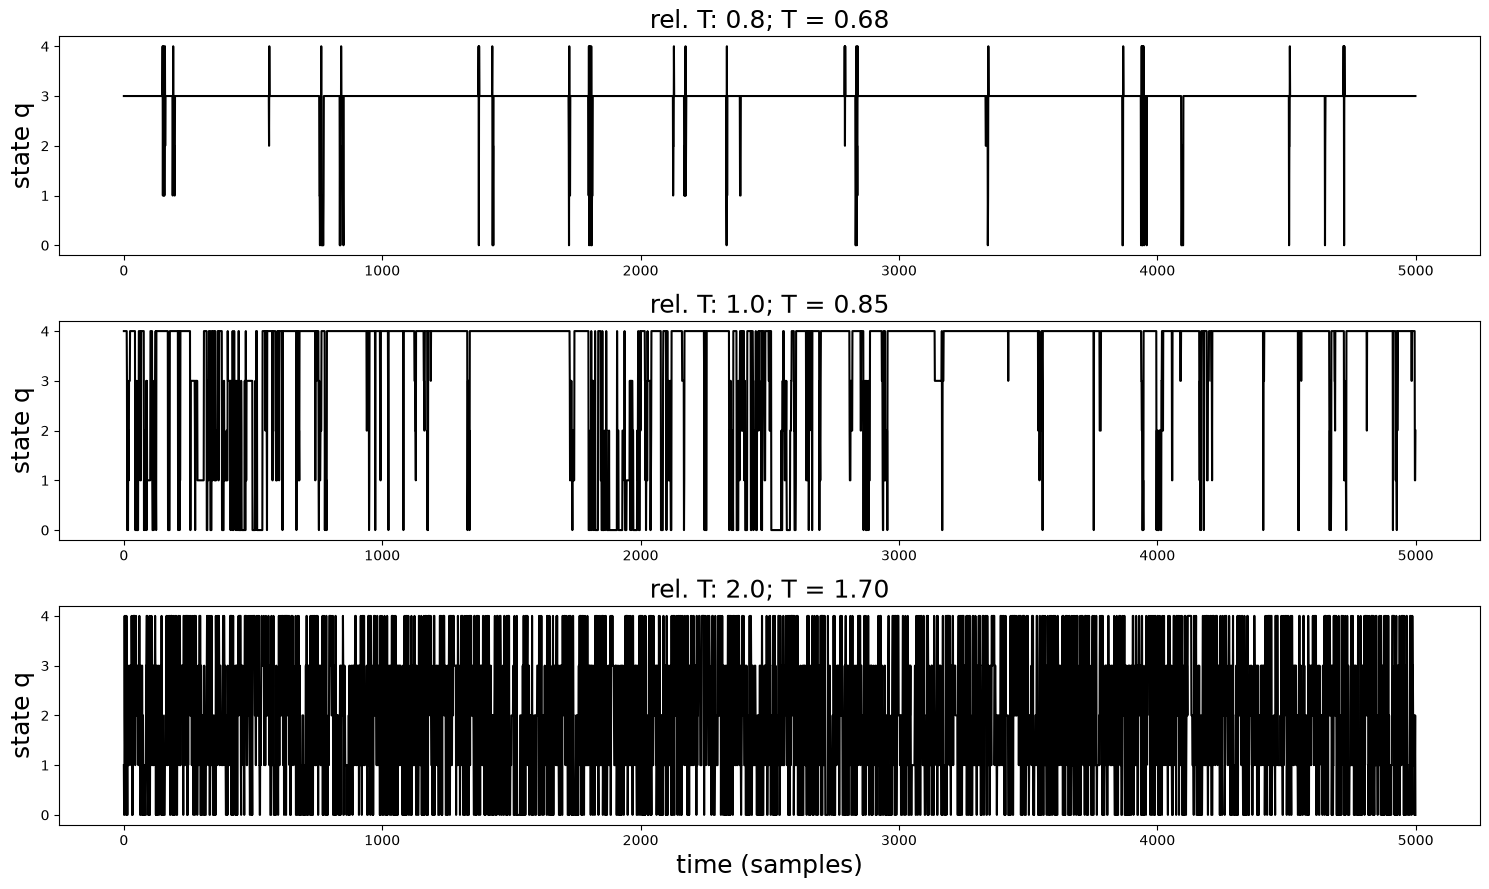

In [2]:
tmax = 5000  # number of samples, cut-off for visibility
rtemp0, rtemp1, rtemp2 = 0.8, 1.0, 2.0
x0 = np.load(f"{data_path}/PottsQ5_Temp_{rtemp0 * Tc:.2f}_Lattice_L25_fm.npy")[:tmax, 3]
x1 = np.load(f"{data_path}/PottsQ5_Temp_{rtemp1 * Tc:.2f}_Lattice_L25_fm.npy")[:tmax, 6]
x2 = np.load(f"{data_path}/PottsQ5_Temp_{rtemp2 * Tc:.2f}_Lattice_L25_fm.npy")[:tmax, 0]

fig, ax = plt.subplots(3, 1, figsize=(15, 9))
for a, x, rtemp in zip(ax, [x0, x1, x2], [rtemp0, rtemp1, rtemp2]):
    a.plot(x, '-k')
    a.set_ylabel("state q", fontsize=18)
    a.set_title(f"rel. T: {rtemp:.1f}; T = {rtemp * Tc:.2f}", fontsize=18)
ax[-1].set_xlabel("time (samples)", fontsize=18)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/04_sample_timecourses.png', dpi=150, bbox_inches='tight')
plt.show()

## Compute entropy rate, excess entropy, LZ complexity, and Hurst exponent

- **Entropy rate / excess entropy**: `mstsa.entropy_rate(x, Q, kmax)` fits joint entropy
  vs. block length over blocks `1..kmax+1` and returns `(er, ee)` -- slope and
  intercept. The original script's `k_hist=6` used history lengths `1..6` (6 points),
  which corresponds to `kmax=5` here (block lengths `1..kmax+1` = `1..6`).
- **LZ76**: `mstsa.lz76(x)` -- normalized Lempel-Ziv complexity.
- **DFA (symbolic)**: `mstsa.dfa(x, lmin, lmax, fitmin, fitmax, nsteps)` -- Hurst
  exponent computed directly on the symbol sequence, same parameters as the original
  script. Unlike the original's `dfa`, `mstsa.dfa` has no guard for a perfectly
  constant input (all fluctuations are 0, so the log-log fit divides by zero and
  returns NaN) -- this happens for the lowest temperature, which is frozen in a
  single state. We replicate the original's guard (`H=0.5` for a constant sequence)
  in a thin wrapper before calling `mstsa.dfa`.
- **DFA (one-hot)**: `mstsa.hurst_exponents_dfa(x, lmin, lmax, fitmin, fitmax, nsteps)`
  -- new in 0.3.0. Instead of running DFA on the symbol labels directly, it builds a
  binary indicator sequence per symbol (`1` where `x==k`, else `0`) and runs DFA on
  each; we average the per-symbol exponents into one value per sample for comparison
  with the symbolic DFA above. Same constant-sequence caveat applies (NaN entries are
  replaced with 0.5 before averaging).

Per-temperature results are cached to disk (`data/cache/potts_complexity/*.npz`).

In [3]:
k_hist = 6  # samples; mstsa kmax = k_hist - 1 (see markdown above)
kmax = k_hist - 1

p_dfa = dict(lmin=50, lmax=2500, fitmin=50, fitmax=2500, nsteps=50)

cache_dir = "../data/cache/potts_complexity"
os.makedirs(cache_dir, exist_ok=True)

_KEYS = ['er', 'ee', 'lzc', 'h', 'h_ohe']


def safe_dfa(x, **kwargs):
    """mstsa.dfa on a constant sequence divides by zero (zero fluctuation at every
    scale) and returns NaN; the reference implementation instead returns H=0.5."""
    if np.all(x == x[0]):
        return 0.5
    return mstsa.dfa(x, **kwargs)


def hurst_ohe_mean(x, **kwargs):
    """Mean of mstsa.hurst_exponents_dfa's per-symbol (one-hot) Hurst exponents,
    with the same constant-indicator NaN -> 0.5 substitution as safe_dfa."""
    with np.errstate(divide='ignore', invalid='ignore'):
        h = mstsa.hurst_exponents_dfa(x, **kwargs)
    return np.where(np.isnan(h), 0.5, h).mean()


def _compute_temp(f_in, Q, kmax, p_dfa, n_samples):
    x = np.load(f_in).astype(np.int32)
    er = np.zeros(n_samples)
    ee = np.zeros(n_samples)
    lzc = np.zeros(n_samples)
    h = np.zeros(n_samples)
    h_ohe = np.zeros(n_samples)
    for j in range(n_samples):
        xj = x[:, j]
        er[j], ee[j] = mstsa.entropy_rate(xj, Q, kmax=kmax)
        lzc[j] = mstsa.lz76(xj)
        h[j] = safe_dfa(xj.astype(np.float64), **p_dfa)
        h_ohe[j] = hurst_ohe_mean(xj, **p_dfa)
    return dict(er=er, ee=ee, lzc=lzc, h=h, h_ohe=h_ohe)


def analyze_temp(rtemp, Q=Q, Tc=Tc, kmax=kmax, p_dfa=p_dfa, n_samples=n_samples,
                  cache_dir=cache_dir, force=False):
    temp = rtemp * Tc
    f_in = f"{data_path}/PottsQ5_Temp_{temp:.2f}_Lattice_L25_fm.npy"
    cache_file = os.path.join(cache_dir, f"rtemp_{rtemp:.2f}.npz")
    if os.path.exists(cache_file) and not force:
        d = np.load(cache_file)
        if all(k in d.files for k in _KEYS):
            return {k: d[k] for k in _KEYS}
    res = _compute_temp(f_in, Q, kmax, p_dfa, n_samples)
    np.savez(cache_file, **res)
    return res


er_arr = np.zeros((n_temps, n_samples))
ee_arr = np.zeros((n_temps, n_samples))
lzc_arr = np.zeros((n_temps, n_samples))
h_arr = np.zeros((n_temps, n_samples))
h_ohe_arr = np.zeros((n_temps, n_samples))

for i, rtemp in enumerate(rtemps):
    print(f"[{i + 1:2d}/{n_temps}] rel. temp: {rtemp:.1f}, temp.: {rtemp * Tc:.2f}")
    res = analyze_temp(rtemp)
    er_arr[i] = res['er']
    ee_arr[i] = res['ee']
    lzc_arr[i] = res['lzc']
    h_arr[i] = res['h']
    h_ohe_arr[i] = res['h_ohe']
print("done.")

[ 1/17] rel. temp: 0.2, temp.: 0.17
[ 2/17] rel. temp: 0.4, temp.: 0.34
[ 3/17] rel. temp: 0.6, temp.: 0.51
[ 4/17] rel. temp: 0.8, temp.: 0.68
[ 5/17] rel. temp: 0.9, temp.: 0.77
[ 6/17] rel. temp: 1.0, temp.: 0.85
[ 7/17] rel. temp: 1.1, temp.: 0.94
[ 8/17] rel. temp: 1.2, temp.: 1.02
[ 9/17] rel. temp: 1.4, temp.: 1.19
[10/17] rel. temp: 1.6, temp.: 1.36
[11/17] rel. temp: 1.8, temp.: 1.53
[12/17] rel. temp: 2.0, temp.: 1.70
[13/17] rel. temp: 2.2, temp.: 1.87
[14/17] rel. temp: 2.4, temp.: 2.04
[15/17] rel. temp: 2.6, temp.: 2.21
[16/17] rel. temp: 2.8, temp.: 2.38
[17/17] rel. temp: 3.0, temp.: 2.55
done.


## Complexity measures vs. relative temperature

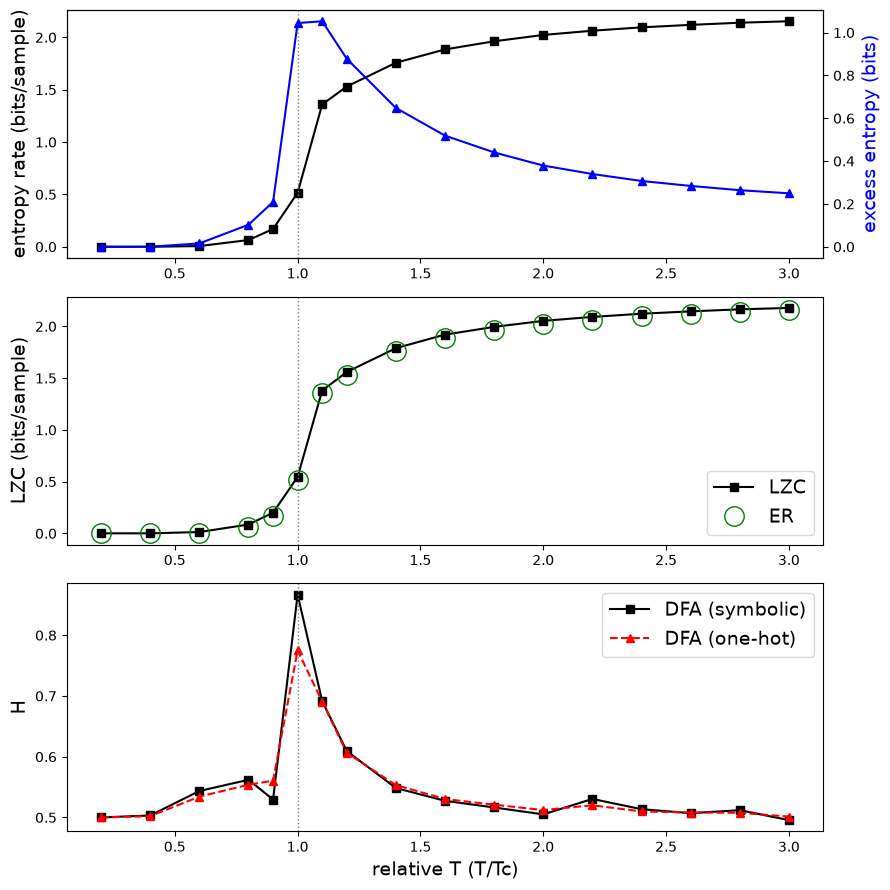

In [4]:
fsize = 14
fig, ax = plt.subplots(3, 1, figsize=(9, 9))

# entropy rate + excess entropy
ax[0].plot(rtemps, er_arr.mean(axis=1), '-sk')
ax[0].set_ylabel("entropy rate (bits/sample)", fontsize=fsize)
ax0c = ax[0].twinx()
ax0c.set_ylabel("excess entropy (bits)", color='b', fontsize=fsize)
ax0c.plot(rtemps, ee_arr.mean(axis=1), '-^b')

# LZC vs ER
ax[1].plot(rtemps, lzc_arr.mean(axis=1), '-sk', label='LZC')
ax[1].plot(rtemps, er_arr.mean(axis=1), 'og', mfc='none', ms=14, label='ER')
ax[1].set_ylabel("LZC (bits/sample)", fontsize=fsize)
ax[1].legend(loc='lower right', fontsize=fsize)

# Hurst exponent: symbolic DFA vs. one-hot (per-symbol) DFA
ax[2].plot(rtemps, h_arr.mean(axis=1), '-sk', label='DFA (symbolic)')
ax[2].plot(rtemps, h_ohe_arr.mean(axis=1), '--^r', label='DFA (one-hot)')
ax[2].set_ylabel("H", fontsize=fsize)
ax[2].set_xlabel("relative T (T/Tc)", fontsize=fsize)
ax[2].legend(loc='upper right', fontsize=fsize)

for a in ax:
    a.axvline(1.0, color='gray', ls=':', lw=1)

plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/04_complexity_vs_temp.png', dpi=150, bbox_inches='tight')
plt.show()